# Image classification

In [1]:
from google.colab import ai
response = ai.generate_text("What is the capital of France?")

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import datasets, layers, models
import numpy as np

In [6]:
(X_train, y_train), (X_test, y_test) = datasets.cifar10.load_data()

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 10s 0us/step


In [7]:
X_test.shape

(10000, 32, 32, 3)

In [8]:
X_train.shape

(50000, 32, 32, 3)

In [9]:
y_train = y_train.reshape(-1, )
y_train[:5]

array([6, 9, 9, 4, 1], dtype=uint8)

In [10]:
classes = ["airplane","automobile","bird","cat","deer","dog","frog","horse","ship","truck"]

In [25]:
def plot_sample(X, y,index):
  plt.figure(figsize=(15,2))
  plt.imshow(X[index])


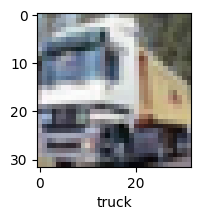

In [12]:
plot_sample(X_train, y_train, 1)

In [13]:
X_train = X_train / 255.0
X_test = X_test / 255.0

In [14]:
ann = models.Sequential([
        layers.Flatten(input_shape=(32,32,3)),
        layers.Dense(3000, activation='relu'),
        layers.Dense(1000, activation='relu'),
        layers.Dense(10, activation='softmax')
    ])

ann.compile(optimizer='SGD',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

ann.fit(X_train, y_train, epochs=5)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 160s 102ms/step - accuracy: 0.3556 - loss: 1.8110
Epoch 2/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 178s 87ms/step - accuracy: 0.4296 - loss: 1.6200
Epoch 3/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 128s 82ms/step - accuracy: 0.4578 - loss: 1.5366
Epoch 4/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 146s 85ms/step - accuracy: 0.4777 - loss: 1.4787
Epoch 5/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 155s 93ms/step - accuracy: 0.4957 - loss: 1.4301


In [15]:
from sklearn.metrics import confusion_matrix , classification_report
import numpy as np
y_pred = ann.predict(X_test)
y_pred_classes = [np.argmax(element) for element in y_pred]

print("Classification Report: \n", classification_report(y_test, y_pred_classes))

313/313 ━━━━━━━━━━━━━━━━━━━━ 10s 33ms/step
Classification Report: 
               precision    recall  f1-score   support

           0       0.64      0.41      0.50      1000
           1       0.69      0.55      0.61      1000
           2       0.32      0.44      0.37      1000
           3       0.30      0.46      0.36      1000
           4       0.54      0.22      0.31      1000
           5       0.50      0.18      0.26      1000
           6       0.38      0.78      0.51      1000
           7       0.67      0.41      0.51      1000
           8       0.53      0.71      0.61      1000
           9       0.60      0.53      0.56      1000

    accuracy                           0.47     10000
   macro avg       0.52      0.47      0.46     10000
weighted avg       0.52      0.47      0.46     10000



In [16]:
cnn = models.Sequential([
    layers.Conv2D(filters=32, kernel_size=(3, 3), activation='relu', input_shape=(32, 32, 3)),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(filters=64, kernel_size=(3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(10, activation='softmax')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [17]:
cnn.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

In [18]:
cnn.fit(X_train, y_train, epochs=5)

Epoch 1/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 68s 43ms/step - accuracy: 0.4793 - loss: 1.4540
Epoch 2/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 67s 43ms/step - accuracy: 0.6077 - loss: 1.1200
Epoch 3/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 82s 43ms/step - accuracy: 0.6607 - loss: 0.9740
Epoch 4/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 67s 43ms/step - accuracy: 0.6920 - loss: 0.8832
Epoch 5/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 65s 41ms/step - accuracy: 0.7187 - loss: 0.8162


In [19]:
cnn.evaluate(X_test, y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 7s 20ms/step - accuracy: 0.6871 - loss: 0.9218


[0.9218272566795349, 0.6870999932289124]

In [20]:
y_pred = cnn.predict(X_test)
y_pred[:5]

313/313 ━━━━━━━━━━━━━━━━━━━━ 6s 20ms/step


array([[3.0852689e-03, 6.4906861e-05, 1.5526176e-02, 8.1377149e-01,
        4.2627617e-03, 1.3899791e-01, 1.3601172e-02, 3.8708810e-04,
        9.8800752e-03, 4.2328064e-04],
       [1.3002789e-03, 5.2326739e-01, 4.1701305e-06, 2.1549957e-05,
        5.7086811e-07, 2.8212438e-07, 7.8612504e-07, 1.9146739e-07,
        4.7202495e-01, 3.3797200e-03],
       [1.6803330e-01, 2.2027616e-01, 1.6930586e-02, 2.5662996e-02,
        3.8643756e-03, 1.6619323e-03, 1.9119304e-03, 3.5951133e-03,
        5.4063213e-01, 1.7431473e-02],
       [4.5650908e-01, 5.6436085e-03, 1.3857907e-01, 2.4182711e-02,
        2.8428553e-02, 1.6203377e-03, 5.1502232e-03, 8.4960693e-04,
        3.3751941e-01, 1.5173270e-03],
       [1.5589943e-05, 2.5557178e-05, 1.7249592e-02, 4.2724013e-02,
        6.5835410e-01, 1.6813697e-02, 2.6472148e-01, 7.9005200e-05,
        8.4756603e-06, 8.4948715e-06]], dtype=float32)

In [21]:
y_classes = [np.argmax(element) for element in y_pred]
y_classes[:5]

[np.int64(3), np.int64(1), np.int64(8), np.int64(0), np.int64(4)]

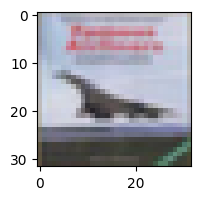

In [31]:
plot_sample(X_test, y_test,3)

In [32]:
classes[y_classes[3]]

'airplane'